# Machine Learning — Chapter 3: Regression & Classification

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.grid'] = True
SEED = 42

# อ่านไฟล์ข้อมูล (อย่าลืมอัปโหลดไฟล์ healthcare-dataset-stroke-data.csv เข้ามาในสภาพแวดล้อมก่อนนะครับ)
df = pd.read_csv('healthcare-dataset-stroke-data.csv')

# เติมค่าว่างใน bmi ด้วย Median และลบ id
df['bmi'] = df['bmi'].fillna(df['bmi'].median())
if 'id' in df.columns:
    df = df.drop(columns=['id'])

# แปลงข้อมูลกลุ่มข้อความให้เป็นตัวเลขด้วย One-Hot Encoding
df_encoded = pd.get_dummies(df, drop_first=True)

print("เตรียมข้อมูลเรียบร้อย! Shape:", df_encoded.shape)
df_encoded.head()

เตรียมข้อมูลเรียบร้อย! Shape: (5110, 13)


,age,hypertension,heart_disease,avg_glucose_level,bmi,gender_Male,gender_Other,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban
0,67.0,0,1,228.69,36.6,True,False,True,False,True,False,False,True
1,61.0,0,0,202.21,28.1,False,False,True,False,False,True,False,False
2,80.0,0,1,105.92,32.5,True,False,True,False,True,False,False,False
3,49.0,0,0,171.23,34.4,False,False,True,False,True,False,False,True
4,79.0,1,0,174.12,24.0,False,False,True,False,False,True,False,False


# LAB 1: Regression (Age Prediction)
หัวข้อ: Simple Linear Regression · Multiple Linear Regression · Age Prediction

In [20]:
# --- Simple Linear Regression ---
X_simple = df[['bmi']] # ใช้ Feature เดียว
y_reg = df['age']      # Target คือ Age (อายุ)

X_train_s, X_test_s, y_train_r, y_test_r = train_test_split(X_simple, y_reg, test_size=0.2, random_state=SEED)

simple_model = LinearRegression()
simple_model.fit(X_train_s, y_train_r)

y_pred_simple = simple_model.predict(X_test_s)
print("--- Simple Linear Regression ---")
print(f"MSE: {mean_squared_error(y_test_r, y_pred_simple):.2f}")
print(f"R2 : {r2_score(y_test_r, y_pred_simple):.4f}")

--- Simple Linear Regression ---
MSE: 463.89
R2 : 0.1165


In [21]:
# --- Multiple Linear Regression ---
# ใช้ปัจจัย: bmi, avg_glucose_level, และตัวแปรทางสุขภาพอื่นๆ 
X_multi = df[['bmi', 'avg_glucose_level', 'hypertension', 'heart_disease']]

X_train_m, X_test_m, _, _ = train_test_split(X_multi, y_reg, test_size=0.2, random_state=SEED)

multi_model = LinearRegression()
multi_model.fit(X_train_m, y_train_r)

y_pred_multi = multi_model.predict(X_test_m)
print("--- Multiple Linear Regression ---")
print(f"MSE: {mean_squared_error(y_test_r, y_pred_multi):.2f}")
print(f"R2 : {r2_score(y_test_r, y_pred_multi):.4f}")

--- Multiple Linear Regression ---
MSE: 401.40
R2 : 0.2356


# LAB 2: Classification (Gender Prediction)
หัวข้อ: Preparing Classification Data · Decision Boundary Visualization · Logistic Regression · Gender Prediction · Confusion Matrix

In [22]:
# --- Preparing Classification Data ---
# ตัดข้อมูลเพศ 'Other' ออก เพื่อทำ Binary Classification (Male / Female)
df_cls = df[df['gender'] != 'Other'].copy()

# แปลงเพศเป็นตัวเลข (Male = 0, Female = 1)
df_cls['gender_encoded'] = df_cls['gender'].map({'Male': 0, 'Female': 1})

# เลือกใช้ 2 Features (อายุ และ ขนาดร่างกาย) เพื่อให้สามารถวาด Decision Boundary แบบ 2D ได้
X_cls = df_cls[['age', 'bmi']]
y_cls = df_cls['gender_encoded']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cls, y_cls, test_size=0.2, random_state=SEED)
print("เตรียมข้อมูลสำหรับ Classification เรียบร้อย! (ทำนายเพศ)")

เตรียมข้อมูลสำหรับ Classification เรียบร้อย! (ทำนายเพศ)


In [23]:
# --- Logistic Regression & Gender Prediction ---
log_model = LogisticRegression()
log_model.fit(X_train_c, y_train_c)

y_pred_c = log_model.predict(X_test_c)

print("--- Gender Prediction Results ---")
print(classification_report(y_test_c, y_pred_c, target_names=['Male', 'Female']))

--- Gender Prediction Results ---
              precision    recall  f1-score   support

        Male       0.00      0.00      0.00       432
      Female       0.58      1.00      0.73       590

    accuracy                           0.58      1022
   macro avg       0.29      0.50      0.37      1022
weighted avg       0.33      0.58      0.42      1022



c:\Users\pamik\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pamik\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pamik\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

c:\Users\pamik\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


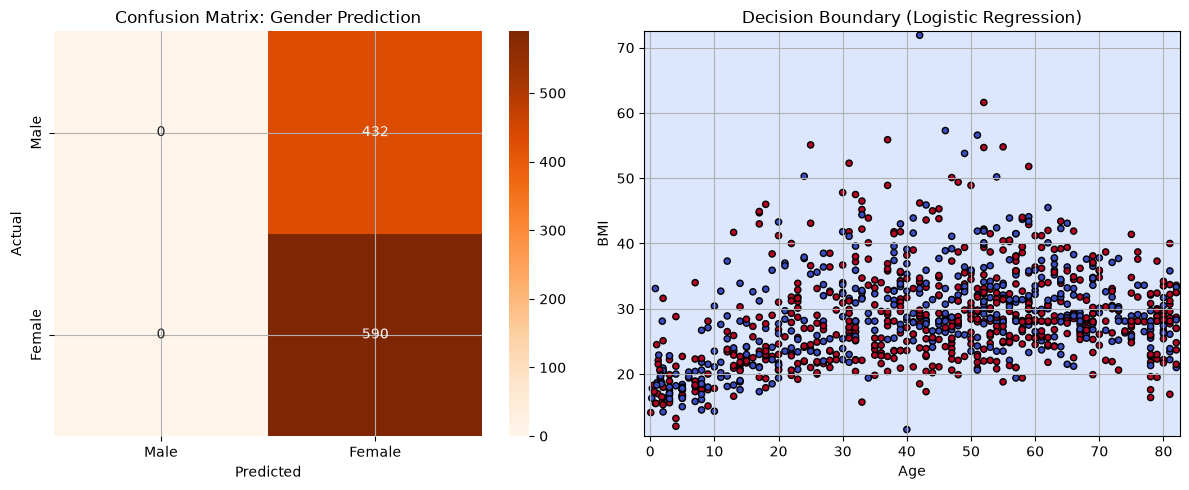

In [24]:
# --- Confusion Matrix ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test_c, y_pred_c), annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Male', 'Female'], yticklabels=['Male', 'Female'])
plt.title('Confusion Matrix: Gender Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# --- Decision Boundary Visualization ---
plt.subplot(1, 2, 2)
x_min, x_max = X_test_c['age'].min() - 1, X_test_c['age'].max() + 1
y_min, y_max = X_test_c['bmi'].min() - 1, X_test_c['bmi'].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.5), np.arange(y_min, y_max, 0.5))

Z = log_model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_test_c['age'], X_test_c['bmi'], c=y_test_c, cmap='coolwarm', edgecolor='k', s=20)
plt.title('Decision Boundary (Logistic Regression)')
plt.xlabel('Age')
plt.ylabel('BMI')

plt.tight_layout()
plt.show()

# LAB 3: Model Comparison
หัวข้อ: Simple vs Multiple Linear Regression · Training vs Testing Performance · Regression vs Classification · Model Performance Metrics

In [27]:
# --- 1. Simple vs Multiple Linear Regression ---
print("--- 1. Simple vs Multiple Linear Regression (R-Squared) ---")
print(f"Simple Linear Regression R2   : {r2_score(y_test_r, y_pred_simple):.4f}")
print(f"Multiple Linear Regression R2 : {r2_score(y_test_r, y_pred_multi):.4f}")
print("-" * 50)

# --- 2. Training vs Testing Performance (Multiple Regression) ---
y_train_pred_multi = multi_model.predict(X_train_m)
print("--- 2. Training vs Testing Performance ---")
print(f"Train R2 Score : {r2_score(y_train_r, y_train_pred_multi):.4f}")
print(f"Test R2 Score  : {r2_score(y_test_r, y_pred_multi):.4f}")
print("*(ถ้า Train ดีมากแต่ Test แย่ แสดงว่าอาจเกิด Overfitting)*")
print("-" * 50)

# --- 3. Model Performance Metrics Summary ---
print("--- 3. Classification Performance Metrics Summary ---")
print(f"Accuracy : {accuracy_score(y_test_c, y_pred_c):.4f}")
print("สรุป: Regression ใช้ทำนายค่าต่อเนื่อง (Age, BMI) ในขณะที่ Classification ใช้จัดกลุ่ม (Gender, Stroke)")

--- 1. Simple vs Multiple Linear Regression (R-Squared) ---
Simple Linear Regression R2   : 0.1165
Multiple Linear Regression R2 : 0.2356
--------------------------------------------------
--- 2. Training vs Testing Performance ---
Train R2 Score : 0.2217
Test R2 Score  : 0.2356
*(ถ้า Train ดีมากแต่ Test แย่ แสดงว่าอาจเกิด Overfitting)*
--------------------------------------------------
--- 3. Classification Performance Metrics Summary ---
Accuracy : 0.5773
สรุป: Regression ใช้ทำนายค่าต่อเนื่อง (Age, BMI) ในขณะที่ Classification ใช้จัดกลุ่ม (Gender, Stroke)
